In [1]:
import numpy as np

import pandas as pd

import tubesml as tml

from source.report import report_victory, yearly_wrapper, _point_to_proba
from source.validate import random_split, yearly_split

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, brier_score_loss
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
class ClassifierModel():
    def __init__(self, pipeline, train_data, test_data, train_target, cv, fit_params=None, early_stopping=False):
        self.pipe = pipeline
        self.train_data = train_data
        self.test_data = test_data
        self.train_target = train_target
        self.cv = cv
        self.fit_params = fit_params
        self.early_stopping = early_stopping

    def fit(self, X=None, y=None):
        cv_score = tml.CrossValidate(data=self.train_data, target=self.train_target, test=self.test_data,
                                 estimator=self.pipe, cv=self.cv, fit_params=self.fit_params,
                                 predict_proba=True,
                                 early_stopping=self.early_stopping, regression=False)

        self.oof, self.pred, _ = cv_score.score()

        return self

    def predict(self, X=None, y=None):
        return self.pred

    
class RegressorModel():
    def __init__(self, pipeline, train_data, test_data, train_target, cv, cutoff, padding, fit_params=None, early_stopping=False):
        self.pipe = pipeline
        self.train_data = train_data
        self.test_data = test_data
        self.train_target = train_target
        self.cv = cv
        self.fit_params = fit_params
        self.early_stopping = early_stopping
        self.cutoff = cutoff
        self.padding = padding

    def fit(self, X=None, y=None):
        cv_score = tml.CrossValidate(data=self.train_data, target=self.train_target, test=self.test_data,
                                 estimator=self.pipe, cv=self.cv, fit_params=self.fit_params,
                                 early_stopping=self.early_stopping, regression=True)

        point_oof, point_pred, _ = cv_score.score()

        self.oof, self.pred = _point_to_proba(oof=point_oof, y_train=self.train_target,
                                    preds=point_pred, clip_val=self.cutoff, padd=self.padding)

        return self

    def predict(self, X=None):
        return self.pred

In [9]:
DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2", "Pred",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

In [10]:
men_train = pd.read_csv("data/processed/men_training.csv")
women_train = pd.read_csv("data/processed/women_training.csv")

men_test = pd.read_csv("data/processed/2026_men_test.csv")
women_test = pd.read_csv("data/processed/2026_women_test.csv")

sub = pd.read_csv("data/march-machine-learning-mania-2026/SampleSubmissionStage2.csv")

# Men Submission

In [11]:
lasso_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", Lasso(random_state=34, alpha=0.1, max_iter=10000))])

lasso_not_imp = [
 'delta_def_edge',
 'delta_OT_win',
 'delta_FGM',
 'delta_Ast_TO_ratio',
 'delta_OT_win_perc',
 'delta_FTA_diff',
 'delta_DR',
 'delta_opp_FTA',
 'delta_quality',
 'delta_Ast_diff',
 'delta_FTA',
 'delta_FTM',
 'delta_FTM_diff',
 'delta_DR_diff',
 'delta_Opp_eff_shooting_perc',
 'delta_Eff_shooting_perc',
 'delta_Ast',
 'delta_True_shooting_perc',
 'delta_TO',
 'delta_Stl',
 'delta_Score',
 'delta_PF_diff',
 'delta_OR',
 'delta_TO_diff',
 'delta_TO_perposs_diff',
 'delta_TO_perposs',
 'delta_off_rating_diff',
 'delta_opp_FGA',
 'delta_FGA3',
 'delta_opp_FGM',
 'delta_Tot_Reb_diff',
 'delta_True_shooting_perc_diff',
 'delta_def_rating',
 'delta_Tot_Reb',
 'delta_FGM3_diff',
 'delta_FGM3',
 'delta_FGA_diff',
 'delta_FGA3_diff',
 'delta_opp_score',
 'delta_possessions',
 'delta_opp_TO',
 'delta_opp_possessions',
 'delta_FG3_ratio',
 'delta_Eff_FG_perc_diff',
 'delta_FGA',
 'delta_FGA2',
 'delta_shtg_opportunity',
 'delta_FGA2_diff',
 'delta_FGM_no_ast_perc',
 'delta_FGM_perc']

lasso_feat = [c for c in men_train if "delta" in c and c not in DROP and c not in lasso_not_imp]

lasso = RegressorModel(pipeline=lasso_pipe,
                            train_data=men_train[lasso_feat],
                            test_data=men_test[lasso_feat],
                            train_target=men_train["target_points"],
                            cv=kfolds, cutoff=32, padding=0.02)

lasso.fit()

pred_lasso = lasso.predict()
oof_lasso = lasso.oof

brier_score_loss(y_true=men_train["target"], y_prob=oof_lasso)

0.18311463846640313

In [12]:
ridge_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", Ridge(random_state=34, alpha=0.1, max_iter=10000))])

ridge_feat = [c for c in men_train if "delta" in c and c not in DROP]

ridge = RegressorModel(pipeline=ridge_pipe,
                            train_data=men_train[ridge_feat],
                            test_data=men_test[ridge_feat],
                            train_target=men_train["target_points"],
                            cv=kfolds, cutoff=21, padding=0.01)

ridge.fit()

pred_ridge = ridge.predict()
oof_ridge = ridge.oof

brier_score_loss(y_true=men_train["target"], y_prob=oof_ridge)

0.182539938870406

In [13]:
model = lgb.LGBMRegressor(n_jobs=-1, random_state=34, n_estimators=10000,
                          learning_rate=0.01,
                         max_depth=115, num_leaves=97,
                         reg_lambda=98, reg_alpha=64,
                         colsample_bytree=0.335, subsample=0.81,
                         min_child_weight=79.7, eval_metric="l2", verbose=-1)

lgb_pipe = Pipeline([
                ('imputer', tml.DfImputer(strategy='mean')),
                ("model", model)])

callbacks = [lgb.early_stopping(100, verbose=0)]
    
fit_params = {"callbacks":callbacks, "eval_metric": "l2"}

lgb_not_imp = [
 'delta_TO_diff',
 'T2_FGA3_diff',
 'T1_FTA',
 'delta_Ast_diff',
 'delta_Tot_Reb',
 'T2_TO_perposs',
 'delta_True_shooting_perc_diff',
 'delta_FGM2',
 'T1_def_rating',
 'T1_FGM_diff',
 'T2_FG3_ratio',
 'T1_opp_score',
 'T2_OR',
 'T2_FGM3',
 'T1_FGM_no_ast_diff',
 'T2_DR',
 'delta_opp_possessions',
 'T2_Tot_Reb',
 'T1_TO_diff',
 'delta_Tot_Reb_diff',
 'T2_FGA2_diff',
 'delta_OT_win',
 'T1_Ast',
 'delta_Ast',
 'T1_FG3_ratio_diff',
 'T2_FG3_ratio_diff',
 'T2_FGA',
 'T1_impact',
 'T1_Tot_Reb',
 'delta_possessions',
 'T1_DR',
 'T2_opp_FGM',
 'T2_Eff_shooting_perc',
 'T2_FT_perc',
 'delta_FTM_diff',
 'T2_Ast',
 'T1_OR_opportunity',
 'T1_FGM3_diff',
 'delta_def_edge',
 'delta_OR_opportunity_diff',
 'T2_FGA3',
 'T2_FGM2',
 'delta_FGM3',
 'T2_FGM_perc',
 'T1_OT_win',
 'T2_N_wins',
 'T2_impact_diff',
 'T2_FGA2',
 'delta_FG3_ratio',
 'T2_Ast_diff',
 'T2_FGM2_perc',
 'delta_def_rating',
 'T1_TO_perposs',
 'delta_DR_diff',
 'T2_Eff_FG_perc_diff',
 'T1_FTA_diff',
 'delta_FGM2_perc',
 'T2_OT_win_perc',
 'T2_OT_win',
 'T2_TO_perposs_diff',
 'delta_FGA3',
 'delta_FGA',
 'T2_FGM3_diff',
 'delta_OT_win_perc',
 'T2_FTM_diff',
 'delta_FGM2_diff',
 'T1_OT_win_perc',
 'stage_Round2',
 'T1_FGM2_perc',
 'stage_Round1',
 'stage_Round3',
 'stage_Round4',
 'stage_final',
 'stage_finalfour',
 'stage_impossible'
]

lgb_feat = [c for c in men_train if c not in DROP and c not in lgb_not_imp]

lgb_mod = RegressorModel(pipeline=lgb_pipe,
                            train_data=men_train[lgb_feat],
                            test_data=men_test[lgb_feat],
                            train_target=men_train["target_points"],
                            fit_params=fit_params, early_stopping=True,
                            cv=kfolds, cutoff=22, padding=0.035)

lgb_mod.fit()

pred_lgb = lgb_mod.predict()
oof_lgb = lgb_mod.oof

brier_score_loss(y_true=men_train["target"], y_prob=oof_lgb)

0.18363172771514738

In [16]:
model = xgb.XGBRegressor(n_jobs=-1, random_state=34, n_estimators=10000,
                         max_depth=3,
                         reg_lambda=39.8, reg_alpha=85.8,
                         colsample_bytree=0.563,
                          colsample_bylevel=0.718,
                          subsample=0.765,
                         min_child_weight=53.36,
                         early_stopping_rounds=100,
                             eval_metric=mean_squared_error)

xgb_pipe = Pipeline([
                ('imputer', tml.DfImputer(strategy='mean')),
                ("model", model)])

    
fit_params = {"verbose": False}

xgb_not_imp = [c for c in men_train if "stage" in c
 
] + [
 
 'T2_OR_opportunity',
 'T2_FGA_diff',
 'T2_FG3_ratio',
 'T1_opp_FGM3',
 'T2_Ast_TO_ratio_diff',
 'T1_FGM3_diff',
 'T2_FGM2',
 'T2_DR_opportunity',
 'T1_Ast_diff',
 'T2_Stl',
 'delta_Score',
 'T2_Eff_FG_perc_diff',
 'T1_OR_opportunity_diff',
 'delta_FTA',
 'T2_def_rating',
 'delta_OT_win_perc',
 'T2_FGA2_diff',
 'T1_OT_win_perc',
 'T1_True_shooting_perc',
 'T1_Stl_diff',
 'T2_Ast',
 'delta_OT_win',
 'T2_OR',
 'T2_FGM',
 'T2_TO_diff',
 'T2_OT_win_perc',
 'T1_opp_score',
 'delta_FG3_ratio',
 'delta_off_edge',
 'T2_FGA2',
 'T1_DR_opportunity_diff',
 'T1_TO',
 'T2_OR_opportunity_diff',
 'T1_FTA_diff',
 'delta_FGM2',
 'T1_Score',
 'delta_FGA2',
 'T2_OT_win',
 'T2_opp_FGM3',
 'T1_possessions',
 'T2_impact_diff',
 'T2_TO_perposs_diff',
 'T2_N_wins',
 'T2_TO_perposs',
 'delta_OR_diff',
 'delta_DR_opportunity',
 'T2_FGM2_perc',
 'delta_FTA_diff',
 'T1_OT_win',
 'T1_FGA3',
 'T1_FG3_ratio_diff',
 'delta_DR',
 'T2_FG3_ratio_diff',
 'T1_N_wins',
 'delta_FGA',
 'T2_Opp_eff_shooting_perc',
 'T1_FGM_diff',
 'delta_opp_possessions',
 'T2_FTM_diff',
 'delta_opp_TO',
 'delta_def_rating',
 'T2_Tot_Reb',
 'delta_opp_FGA',
 'T2_FTA_diff',
 'T1_Tot_Reb']

xgb_feat = [c for c in men_train if c not in DROP and c not in xgb_not_imp]

xgb_mod = RegressorModel(pipeline=xgb_pipe,
                            train_data=men_train[xgb_feat],
                            test_data=men_test[xgb_feat],
                            train_target=men_train["target_points"],
                            fit_params=fit_params, early_stopping=True,
                            cv=kfolds, cutoff=46, padding=0.013)

xgb_mod.fit()

pred_xgb = xgb_mod.predict()
oof_xgb = xgb_mod.oof

brier_score_loss(y_true=men_train["target"], y_prob=oof_xgb)

0.18562166424170434

In [23]:
model = LogisticRegression(C=0.67, random_state=34, max_iter=10000, n_jobs=-1)

logit_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", model)])

logit_not_imp = ['delta_True_shooting_perc',
 'delta_opp_FTA',
 'delta_off_edge',
 'delta_FGM2_diff',
 'delta_Tot_Reb',
 'delta_possessions',
 'delta_opp_possessions',
 'delta_Ast_TO_ratio_diff',
 'delta_Ast_TO_ratio',
 'delta_quality']

logit_feat = [c for c in men_train if c not in DROP and c not in logit_not_imp]

logit = ClassifierModel(pipeline=logit_pipe,
                            train_data=men_train[logit_feat],
                            test_data=men_test[logit_feat],
                            train_target=men_train["target"],
                            cv=kfolds)

logit.fit()

pred_logit = logit.predict()
oof_logit = logit.oof

brier_score_loss(y_true=men_train["target"], y_prob=oof_logit)

0.19240080528449213

In [26]:
len(pred_logit)

66430

In [29]:
oof_men = (oof_logit + oof_xgb + oof_lgb + oof_ridge + oof_lasso) / 5
pred_men = (pred_logit + pred_xgb + pred_lgb + pred_ridge + pred_lasso) / 5

brier_score_loss(y_true=men_train["target"], y_prob=oof_men)

0.1824772808348436

In [31]:
men_test["Pred"] = pred_men

men_test[["ID", "Pred"]]

,ID,Pred
0,2026_1101_1102,0.751970
1,2026_1101_1103,0.058975
2,2026_1101_1104,0.068446
3,2026_1101_1105,0.616361
4,2026_1101_1106,0.633804
...,...,...
66425,2026_1478_1480,0.371136
66426,2026_1478_1481,0.397182
66427,2026_1479_1480,0.584634
66428,2026_1479_1481,0.607913


<Axes: >

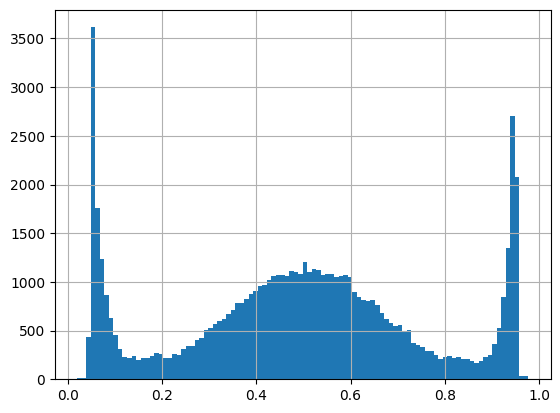

In [33]:
men_test["Pred"].hist(bins=100)

# Women Submission

In [34]:
lasso_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", Lasso(random_state=34, alpha=0.1, max_iter=10000))])

lasso_not_imp = [
 'delta_def_edge',
 'delta_OT_win',
 'delta_FGM',
 'delta_Ast_TO_ratio',
 'delta_OT_win_perc',
 'delta_FTA_diff',
 'delta_DR',
 'delta_opp_FTA',
 'delta_quality',
 'delta_Ast_diff',
 'delta_FTA',
 'delta_FTM',
 'delta_FTM_diff',
 'delta_DR_diff',
 'delta_Opp_eff_shooting_perc',
 'delta_Eff_shooting_perc',
 'delta_Ast',
 'delta_True_shooting_perc',
 'delta_TO',
 'delta_Stl',
 'delta_Score',
 'delta_PF_diff',
 'delta_OR',
 'delta_TO_diff',
 'delta_TO_perposs_diff',
 'delta_TO_perposs',
 'delta_off_rating_diff',
 'delta_opp_FGA',
 'delta_FGA3',
 'delta_opp_FGM',
 'delta_Tot_Reb_diff',
 'delta_True_shooting_perc_diff',
 'delta_def_rating',
 'delta_Tot_Reb',
 'delta_FGM3_diff',
 'delta_FGM3',
 'delta_FGA_diff',
 'delta_FGA3_diff',
 'delta_opp_score',
 'delta_possessions',
 'delta_opp_TO',
 'delta_opp_possessions',
 'delta_FG3_ratio',
 'delta_Eff_FG_perc_diff',
 'delta_FGA',
 'delta_FGA2',
 'delta_shtg_opportunity',
 'delta_FGA2_diff',
 'delta_FGM_no_ast_perc',
 'delta_FGM_perc']

lasso_feat = [c for c in women_train if "delta" in c and c not in DROP and c not in lasso_not_imp]

lasso = RegressorModel(pipeline=lasso_pipe,
                            train_data=women_train[lasso_feat],
                            test_data=women_test[lasso_feat],
                            train_target=women_train["target_points"],
                            cv=kfolds, cutoff=28, padding=0.01)

lasso.fit()

pred_lasso = lasso.predict()
oof_lasso = lasso.oof

brier_score_loss(y_true=women_train["target"], y_prob=oof_lasso)


0.13708431677080113

In [35]:
model = LogisticRegression(C=0.95, random_state=34, max_iter=10000, n_jobs=-1)

logit_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", model)])

logit_not_imp = ['delta_FGM2',
 'delta_Ast',
 'delta_Score',
 'delta_off_edge',
 'delta_opp_FGA'
 'delta_FGM_perc',
 'delta_FGM_no_ast_diff',
 'delta_TO_perposs_diff',
 'delta_Blk',
 'delta_Opp_eff_shooting_perc',
 'delta_PF',
 'delta_Tot_Reb_diff',
 'delta_off_rating_diff',
 'delta_opp_score',
 'delta_off_rating',
 'delta_opp_possessions',
 'delta_possessions',
 'delta_Tot_Reb',
 'delta_Eff_shooting_perc',
 'delta_def_edge',
 'delta_FGM',
 'delta_quality',
 'delta_possessions_diff',
 'delta_FGM3_diff',
 'delta_Stl_diff']

logit_feat = [c for c in women_train if c not in DROP and c not in logit_not_imp]

logit = ClassifierModel(pipeline=logit_pipe,
                            train_data=women_train[logit_feat],
                            test_data=women_test[logit_feat],
                            train_target=women_train["target"],
                            cv=kfolds)

logit.fit()

pred_logit = logit.predict()
oof_logit = logit.oof

brier_score_loss(y_true=women_train["target"], y_prob=oof_logit)

0.15084982154193888

In [38]:
oof_women = oof_lasso
pred_women = pred_lasso

brier_score_loss(y_true=women_train["target"], y_prob=oof_women)

0.13708431677080113

In [39]:
women_test["Pred"] = pred_women

women_test[["ID", "Pred"]]

,ID,Pred
0,2026_3101_3102,0.456843
1,2026_3101_3103,0.580642
2,2026_3101_3104,0.017632
3,2026_3101_3105,0.611477
4,2026_3101_3106,0.729080
...,...,...
65698,2026_3478_3480,0.404773
65699,2026_3478_3481,0.206194
65700,2026_3479_3480,0.392189
65701,2026_3479_3481,0.195820


<Axes: >

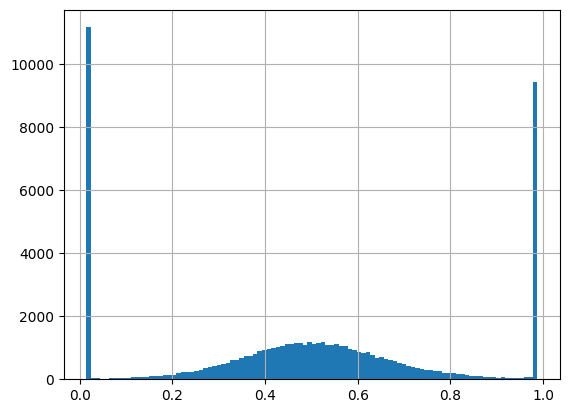

In [40]:
women_test["Pred"].hist(bins=100)

# Final Submission

In [42]:
sub = sub.drop("Pred", axis=1)
sub

,ID
0,2026_1101_1102
1,2026_1101_1103
2,2026_1101_1104
3,2026_1101_1105
4,2026_1101_1106
...,...
132128,2026_3478_3480
132129,2026_3478_3481
132130,2026_3479_3480
132131,2026_3479_3481


In [43]:
all_pred = pd.concat([men_test[["ID", "Pred"]], women_test[["ID", "Pred"]]], ignore_index=True)

all_pred

,ID,Pred
0,2026_1101_1102,0.751970
1,2026_1101_1103,0.058975
2,2026_1101_1104,0.068446
3,2026_1101_1105,0.616361
4,2026_1101_1106,0.633804
...,...,...
132128,2026_3478_3480,0.404773
132129,2026_3478_3481,0.206194
132130,2026_3479_3480,0.392189
132131,2026_3479_3481,0.195820


In [44]:
sub = pd.merge(sub, all_pred, on="ID", how="left")
print(sub.isna().any())
sub

ID      False
Pred    False
dtype: bool


,ID,Pred
0,2026_1101_1102,0.751970
1,2026_1101_1103,0.058975
2,2026_1101_1104,0.068446
3,2026_1101_1105,0.616361
4,2026_1101_1106,0.633804
...,...,...
132128,2026_3478_3480,0.404773
132129,2026_3478_3481,0.206194
132130,2026_3479_3480,0.392189
132131,2026_3479_3481,0.195820


<Axes: >

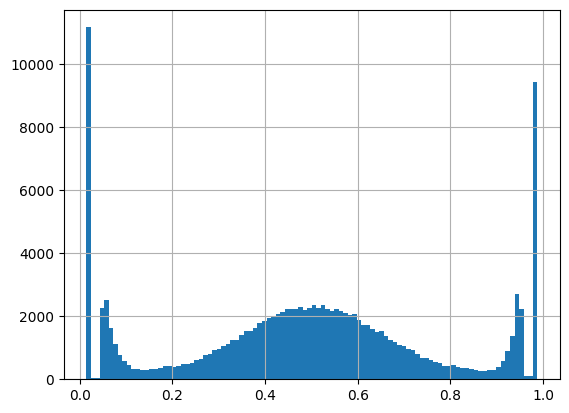

In [45]:
sub["Pred"].hist(bins=100)

In [46]:
sub.to_csv("data/results/2026_submission.csv", index=False)